EMPATICA

In [1]:
"""
Overlapping-window generator for Empatica (E4) and RespiBan physiological signals.

Works for BOTH devices with the SAME core function `sliding_window()`.
Handles:
  - RespiBan .txt file (header line = JSON comment, then whitespace-separated data,
    all channels sampled at the SAME rate, e.g. 700 Hz).
  - Empatica .csv files (each signal in its own file: row0 = start timestamp,
    row1 = sampling rate, rest = data). ACC has 3 columns (x,y,z).
  - Empatica IBI.csv, which is NOT regularly sampled (time, ibi_value pairs) and
    is windowed by timestamp instead of by sample count.

Output: a dict {signal_name: windows_array} per device, where windows_array has
shape (n_windows, window_len) for 1-D signals or (n_windows, window_len, n_channels)
for multi-channel signals (e.g. ACC). IBI windows are returned as a list of
variable-length arrays (one array of ibi values per window).

USAGE (see bottom of file):
    python windowing.py
"""

import json
import numpy as np
import pandas as pd
import os


# ----------------------------------------------------------------------------
# 1. CORE, DEVICE-AGNOSTIC WINDOWING FUNCTION
# ----------------------------------------------------------------------------
def sliding_window(signal, fs, window_sec=5, overlap=0.5):
    """
    Slice a regularly-sampled 1-D or 2-D signal into overlapping windows.

    Parameters
    ----------
    signal : np.ndarray, shape (n_samples,) or (n_samples, n_channels)
    fs : float           sampling rate in Hz
    window_sec : float   window length in seconds (default 5)
    overlap : float      fraction of overlap between consecutive windows,
                          e.g. 0.5 = 50% overlap (default), 0 = no overlap

    Returns
    -------
    windows : np.ndarray, shape (n_windows, window_len) or
              (n_windows, window_len, n_channels)
    """
    signal = np.asarray(signal)
    if signal.ndim == 1:
        signal = signal[:, None]  # -> (n_samples, 1) for uniform handling
        squeeze = True
    else:
        squeeze = False

    window_len = int(round(window_sec * fs))
    step = int(round(window_len * (1 - overlap)))
    if step <= 0:
        raise ValueError("overlap too large â€” step size becomes 0")

    n_samples = signal.shape[0]
    starts = range(0, n_samples - window_len + 1, step)

    windows = np.stack([signal[s:s + window_len] for s in starts], axis=0)

    if squeeze:
        windows = windows[:, :, 0]  # back to (n_windows, window_len)
    return windows


def sliding_window_by_time(timestamps, values, window_sec=5, overlap=0.5,
                            total_duration=None):
    """
    Window an IRREGULARLY sampled signal (e.g. Empatica IBI) by wall-clock time
    instead of by sample count. Each window is a variable-length array of the
    values whose timestamp falls inside [w_start, w_start + window_sec).

    Parameters
    ----------
    timestamps : np.ndarray  seconds since recording start, one per value
    values : np.ndarray      the corresponding values (e.g. ibi in seconds)
    window_sec : float
    overlap : float
    total_duration : float, optional  overrides the max timestamp as the
                      recording length (useful to align with other signals)

    Returns
    -------
    list of np.ndarray â€” one array per window (may be empty if no events fall
    in that window)
    """
    timestamps = np.asarray(timestamps)
    values = np.asarray(values)

    step = window_sec * (1 - overlap)
    if step <= 0:
        raise ValueError("overlap too large â€” step size becomes 0")

    end_time = total_duration if total_duration is not None else timestamps.max()

    windows = []
    w_start = 0.0
    while w_start + window_sec <= end_time + 1e-9:
        mask = (timestamps >= w_start) & (timestamps < w_start + window_sec)
        windows.append(values[mask])
        w_start += step
    return windows


# ----------------------------------------------------------------------------
# 2. EMPATICA LOADER
# ----------------------------------------------------------------------------
def load_empatica_csv(filepath):
    """
    Standard Empatica E4 export format for ACC / BVP / EDA / HR / TEMP:
        row0 = start timestamp (repeated per column)
        row1 = sampling rate Hz (repeated per column)
        row2.. = data samples

    IBI.csv is different: row0 = start timestamp (single value),
    then each row = "time_since_start, ibi_value".

    Returns
    -------
    (data, fs, start_ts)  for regular signals
    (timestamps, ibi_values, start_ts)  for IBI (fs is returned as None)
    """
    fname = os.path.basename(filepath).upper()

    if fname.startswith("IBI"):
        with open(filepath) as f:
            start_ts = float(f.readline().strip().split(",")[0])
        df = pd.read_csv(filepath, skiprows=1, header=None,
                          names=["t_since_start", "ibi"])
        return df["t_since_start"].values, df["ibi"].values, start_ts, None

    raw = pd.read_csv(filepath, header=None)
    start_ts = raw.iloc[0, 0]
    fs = raw.iloc[1, 0]
    data = raw.iloc[2:].values.astype(float)

    if data.shape[1] == 1:
        data = data[:, 0]  # 1-D signal (EDA, TEMP, BVP, HR)

    return data, fs, start_ts


def window_empatica_subject(empatica_dir, window_sec=5, overlap=0.5):
    """
    Loads and windows every Empatica signal in a subject's E4 export folder
    (ACC.csv, BVP.csv, EDA.csv, HR.csv, IBI.csv, TEMP.csv).
    """
    results = {}
    signal_files = {
        "acc": "ACC.csv",
        "bvp": "BVP.csv",
        "eda": "EDA.csv",
        "hr": "HR.csv",
        "temp": "TEMP.csv",
        "ibi": "IBI.csv",
    }

    for name, fname in signal_files.items():
        fpath = os.path.join(empatica_dir, fname)
        if not os.path.exists(fpath):
            print(f"[skip] {fpath} not found")
            continue

        if name == "ibi":
            t, vals, start_ts, _ = load_empatica_csv(fpath)
            windows = sliding_window_by_time(t, vals, window_sec, overlap)
        else:
            data, fs, start_ts = load_empatica_csv(fpath)
            windows = sliding_window(data, fs, window_sec, overlap)

        results[name] = windows
        n = len(windows)
        print(f"[empatica] {name}: {n} windows")

    return results


# ----------------------------------------------------------------------------
# 3. RESPIBAN LOADER
# ----------------------------------------------------------------------------
def load_respiban_txt(filepath):
    """
    Parses a RespiBan/OpenSignals .txt export. WESAD files may start with
    a plain comment line, then a commented JSON metadata line, then data.

    Returns
    -------
    df : DataFrame with one column per sensor (already mapped from CHn -> name)
    fs : sampling rate (Hz), same for all channels
    """
    header = None
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            stripped = line.strip()
            if not stripped.startswith("#") or "{" not in stripped:
                continue
            header_json = stripped.lstrip("#").strip()
            try:
                header = json.loads(header_json)
                break
            except json.JSONDecodeError:
                continue

    if header is None:
        raise ValueError(f"Could not find JSON metadata header in {filepath}")

    device_mac = list(header.keys())[0]
    meta = header[device_mac]

    fs = meta["sampling rate"]
    sensors = meta["sensor"]
    columns = meta["column"]

    ch_cols = [c for c in columns if c.startswith("CH")]
    xyz_axes = iter(["ACC_x", "ACC_y", "ACC_z"])
    ch_to_name = {}
    for ch, sensor in zip(ch_cols, sensors):
        ch_to_name[ch] = next(xyz_axes) if sensor == "XYZ" else sensor

    data = pd.read_csv(filepath, sep=r"\s+", comment="#", header=None, names=columns)
    data = data.rename(columns=ch_to_name)
    return data, fs

def window_respiban_subject(respiban_txt_path, window_sec=5, overlap=0.5):
    """
    Loads and windows every RespiBan signal (ECG, EDA, EMG, TEMP, ACC(x,y,z),
    RESPIRATION) from a single .txt file. All channels share the same fs.
    """
    df, fs = load_respiban_txt(respiban_txt_path)
    results = {}

    signal_map = {
        "ecg": ["ECG"],
        "eda": ["EDA"],
        "emg": ["EMG"],
        "temp": ["TEMP"],
        "resp": ["RESPIRATION"],
        "acc": ["ACC_x", "ACC_y", "ACC_z"],
    }

    for name, cols in signal_map.items():
        missing = [c for c in cols if c not in df.columns]
        if missing:
            print(f"[skip] respiban columns missing for {name}: {missing}")
            continue
        sig = df[cols].values
        windows = sliding_window(sig, fs, window_sec, overlap)
        results[name] = windows
        print(f"[respiban] {name}: {len(windows)} windows")

    return results


# ----------------------------------------------------------------------------
# 4. EXAMPLE USAGE
# ----------------------------------------------------------------------------
if __name__ == "__main__":
    WINDOW_SEC = 5
    OVERLAP = 0.5  # 50% overlap; set to 0 for non-overlapping windows

    # --- adjust these paths to your data ---
    EMPATICA_DIR = "../Data/raw/WESAD/S2/S2_E4_Data"       # folder containing ACC.csv, EDA.csv, ...
    RESPIBAN_TXT = "../Data/raw/WESAD/S2/S2_respiban.txt"  # single .txt file with all RespiBan signals

    all_windows = {}

    if os.path.isdir(EMPATICA_DIR):
        all_windows["empatica"] = window_empatica_subject(
            EMPATICA_DIR, WINDOW_SEC, OVERLAP
        )

    if os.path.isfile(RESPIBAN_TXT):
        all_windows["respiban"] = window_respiban_subject(
            RESPIBAN_TXT, WINDOW_SEC, OVERLAP
        )

    # Example: save each signal's windows as .npy for later use
    # (IBI windows are variable-length, so saved as an object array instead)
    out_dir = "windowed_output"
    os.makedirs(out_dir, exist_ok=True)
    for device, sig_dict in all_windows.items():
        for sig_name, windows in sig_dict.items():
            if sig_name == "ibi":
                arr = np.array(windows, dtype=object)
            else:
                arr = windows
            np.save(os.path.join(out_dir, f"{device}_{sig_name}.npy"), arr,
                     allow_pickle=(sig_name == "ibi"))

    print("\nDone. Windowed arrays saved to:", out_dir)

[empatica] acc: 3148 windows
[empatica] bvp: 3148 windows
[empatica] eda: 3148 windows
[empatica] hr: 3931 windows
[empatica] temp: 3148 windows
[empatica] ibi: 3141 windows


[respiban] ecg: 2537 windows
[respiban] eda: 2537 windows
[respiban] emg: 2537 windows
[respiban] temp: 2537 windows
[respiban] resp: 2537 windows
[respiban] acc: 2537 windows



Done. Windowed arrays saved to: windowed_output


[empatica] acc: 3148 windows
[empatica] bvp: 3148 windows
[empatica] eda: 3148 windows
[empatica] hr: 3931 windows
[empatica] temp: 3148 windows
[empatica] ibi: 3141 windows


[respiban] ecg: 2537 windows
[respiban] eda: 2537 windows
[respiban] emg: 2537 windows
[respiban] temp: 2537 windows
[respiban] resp: 2537 windows
[respiban] acc: 2537 windows



Done. Windowed arrays saved to: windowed_output
saved plot -> windowed_output\plots\empatica_eda_windows.png


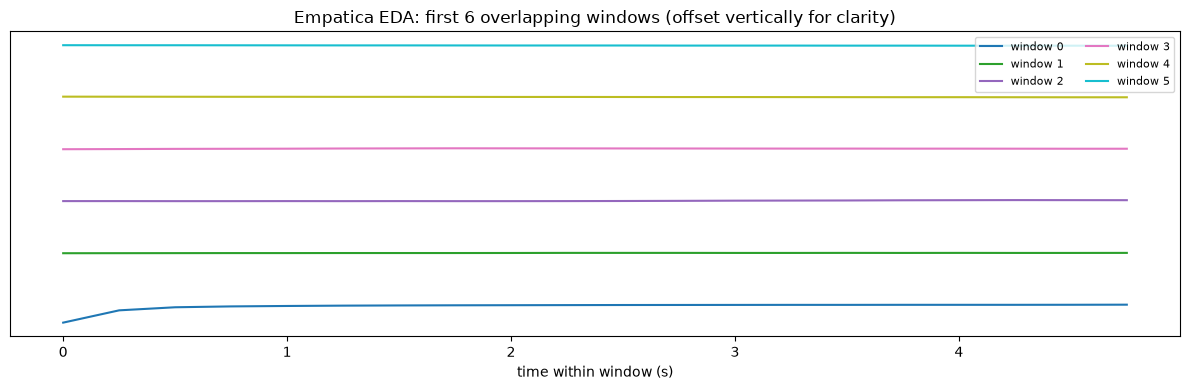

saved plot -> windowed_output\plots\respiban_ecg_windows.png


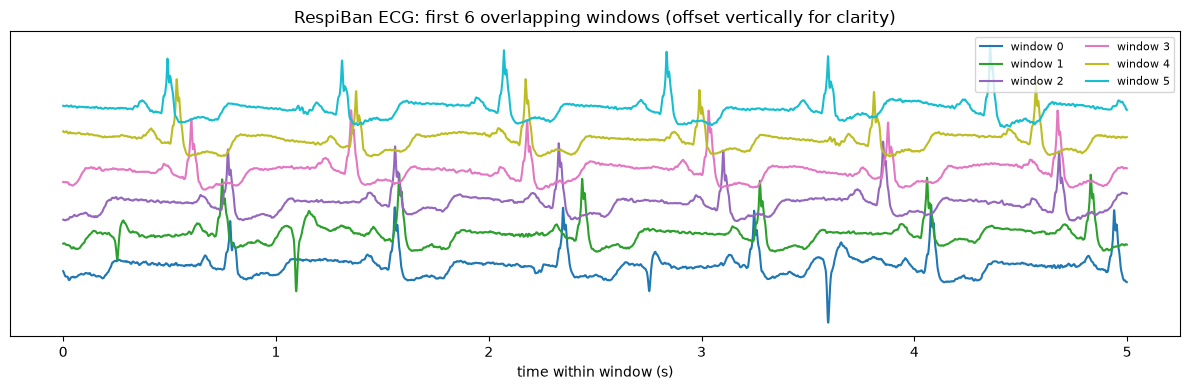

In [2]:
"""
Overlapping-window generator for Empatica (E4) and RespiBan physiological signals.

Works for BOTH devices with the SAME core function `sliding_window()`.
Handles:
  - RespiBan .txt file (header line = JSON comment, then whitespace-separated data,
    all channels sampled at the SAME rate, e.g. 700 Hz).
  - Empatica .csv files (each signal in its own file: row0 = start timestamp,
    row1 = sampling rate, rest = data). ACC has 3 columns (x,y,z).
  - Empatica IBI.csv, which is NOT regularly sampled (time, ibi_value pairs) and
    is windowed by timestamp instead of by sample count.

Output: a dict {signal_name: windows_array} per device, where windows_array has
shape (n_windows, window_len) for 1-D signals or (n_windows, window_len, n_channels)
for multi-channel signals (e.g. ACC). IBI windows are returned as a list of
variable-length arrays (one array of ibi values per window).

USAGE (see bottom of file):
    python windowing.py
"""

import json
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------------
# 1. CORE, DEVICE-AGNOSTIC WINDOWING FUNCTION
# ----------------------------------------------------------------------------
def sliding_window(signal, fs, window_sec=5, overlap=0.5):
    """
    Slice a regularly-sampled 1-D or 2-D signal into overlapping windows.

    Parameters
    ----------
    signal : np.ndarray, shape (n_samples,) or (n_samples, n_channels)
    fs : float           sampling rate in Hz
    window_sec : float   window length in seconds (default 5)
    overlap : float      fraction of overlap between consecutive windows,
                          e.g. 0.5 = 50% overlap (default), 0 = no overlap

    Returns
    -------
    windows : np.ndarray, shape (n_windows, window_len) or
              (n_windows, window_len, n_channels)
    """
    signal = np.asarray(signal)
    if signal.ndim == 1:
        signal = signal[:, None]  # -> (n_samples, 1) for uniform handling
        squeeze = True
    else:
        squeeze = False

    window_len = int(round(window_sec * fs))
    step = int(round(window_len * (1 - overlap)))
    if step <= 0:
        raise ValueError("overlap too large â€” step size becomes 0")

    n_samples = signal.shape[0]
    starts = range(0, n_samples - window_len + 1, step)

    windows = np.stack([signal[s:s + window_len] for s in starts], axis=0)

    if squeeze:
        windows = windows[:, :, 0]  # back to (n_windows, window_len)
    return windows


def sliding_window_by_time(timestamps, values, window_sec=5, overlap=0.5,
                            total_duration=None):
    """
    Window an IRREGULARLY sampled signal (e.g. Empatica IBI) by wall-clock time
    instead of by sample count. Each window is a variable-length array of the
    values whose timestamp falls inside [w_start, w_start + window_sec).

    Parameters
    ----------
    timestamps : np.ndarray  seconds since recording start, one per value
    values : np.ndarray      the corresponding values (e.g. ibi in seconds)
    window_sec : float
    overlap : float
    total_duration : float, optional  overrides the max timestamp as the
                      recording length (useful to align with other signals)

    Returns
    -------
    list of np.ndarray â€” one array per window (may be empty if no events fall
    in that window)
    """
    timestamps = np.asarray(timestamps)
    values = np.asarray(values)

    step = window_sec * (1 - overlap)
    if step <= 0:
        raise ValueError("overlap too large â€” step size becomes 0")

    end_time = total_duration if total_duration is not None else timestamps.max()

    windows = []
    w_start = 0.0
    while w_start + window_sec <= end_time + 1e-9:
        mask = (timestamps >= w_start) & (timestamps < w_start + window_sec)
        windows.append(values[mask])
        w_start += step
    return windows


# ----------------------------------------------------------------------------
# 2. EMPATICA LOADER
# ----------------------------------------------------------------------------
def load_empatica_csv(filepath):
    """
    Standard Empatica E4 export format for ACC / BVP / EDA / HR / TEMP:
        row0 = start timestamp (repeated per column)
        row1 = sampling rate Hz (repeated per column)
        row2.. = data samples

    IBI.csv is different: row0 = start timestamp (single value),
    then each row = "time_since_start, ibi_value".

    Returns
    -------
    (data, fs, start_ts)  for regular signals
    (timestamps, ibi_values, start_ts)  for IBI (fs is returned as None)
    """
    fname = os.path.basename(filepath).upper()

    if fname.startswith("IBI"):
        with open(filepath) as f:
            start_ts = float(f.readline().strip().split(",")[0])
        df = pd.read_csv(filepath, skiprows=1, header=None,
                          names=["t_since_start", "ibi"])
        return df["t_since_start"].values, df["ibi"].values, start_ts, None

    raw = pd.read_csv(filepath, header=None)
    start_ts = raw.iloc[0, 0]
    fs = raw.iloc[1, 0]
    data = raw.iloc[2:].values.astype(float)

    if data.shape[1] == 1:
        data = data[:, 0]  # 1-D signal (EDA, TEMP, BVP, HR)

    return data, fs, start_ts


def window_empatica_subject(empatica_dir, window_sec=5, overlap=0.5):
    """
    Loads and windows every Empatica signal in a subject's E4 export folder
    (ACC.csv, BVP.csv, EDA.csv, HR.csv, IBI.csv, TEMP.csv).
    """
    results = {}
    signal_files = {
        "acc": "ACC.csv",
        "bvp": "BVP.csv",
        "eda": "EDA.csv",
        "hr": "HR.csv",
        "temp": "TEMP.csv",
        "ibi": "IBI.csv",
    }

    for name, fname in signal_files.items():
        fpath = os.path.join(empatica_dir, fname)
        if not os.path.exists(fpath):
            print(f"[skip] {fpath} not found")
            continue

        if name == "ibi":
            t, vals, start_ts, _ = load_empatica_csv(fpath)
            windows = sliding_window_by_time(t, vals, window_sec, overlap)
        else:
            data, fs, start_ts = load_empatica_csv(fpath)
            windows = sliding_window(data, fs, window_sec, overlap)

        results[name] = windows
        n = len(windows)
        print(f"[empatica] {name}: {n} windows")

    return results


# ----------------------------------------------------------------------------
# 3. RESPIBAN LOADER
# ----------------------------------------------------------------------------
def load_respiban_txt(filepath):
    """
    Parses a RespiBan/OpenSignals .txt export. WESAD files may start with
    a plain comment line, then a commented JSON metadata line, then data.

    Returns
    -------
    df : DataFrame with one column per sensor (already mapped from CHn -> name)
    fs : sampling rate (Hz), same for all channels
    """
    header = None
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            stripped = line.strip()
            if not stripped.startswith("#") or "{" not in stripped:
                continue
            header_json = stripped.lstrip("#").strip()
            try:
                header = json.loads(header_json)
                break
            except json.JSONDecodeError:
                continue

    if header is None:
        raise ValueError(f"Could not find JSON metadata header in {filepath}")

    device_mac = list(header.keys())[0]
    meta = header[device_mac]

    fs = meta["sampling rate"]
    sensors = meta["sensor"]
    columns = meta["column"]

    ch_cols = [c for c in columns if c.startswith("CH")]
    xyz_axes = iter(["ACC_x", "ACC_y", "ACC_z"])
    ch_to_name = {}
    for ch, sensor in zip(ch_cols, sensors):
        ch_to_name[ch] = next(xyz_axes) if sensor == "XYZ" else sensor

    data = pd.read_csv(filepath, sep=r"\s+", comment="#", header=None, names=columns)
    data = data.rename(columns=ch_to_name)
    return data, fs

def window_respiban_subject(respiban_txt_path, window_sec=5, overlap=0.5):
    """
    Loads and windows every RespiBan signal (ECG, EDA, EMG, TEMP, ACC(x,y,z),
    RESPIRATION) from a single .txt file. All channels share the same fs.
    """
    df, fs = load_respiban_txt(respiban_txt_path)
    results = {}

    signal_map = {
        "ecg": ["ECG"],
        "eda": ["EDA"],
        "emg": ["EMG"],
        "temp": ["TEMP"],
        "resp": ["RESPIRATION"],
        "acc": ["ACC_x", "ACC_y", "ACC_z"],
    }

    for name, cols in signal_map.items():
        missing = [c for c in cols if c not in df.columns]
        if missing:
            print(f"[skip] respiban columns missing for {name}: {missing}")
            continue
        sig = df[cols].values
        windows = sliding_window(sig, fs, window_sec, overlap)
        results[name] = windows
        print(f"[respiban] {name}: {len(windows)} windows")

    return results


# ----------------------------------------------------------------------------
# 4. PLOTTING
# ----------------------------------------------------------------------------
def plot_window_overlap(windows, fs, signal_name="signal", n_windows=6,
                         channel=0, save_path=None):
    """
    Visualizes how consecutive windows overlap in time. Plots the first
    `n_windows` windows stitched onto a shared time axis, each in a
    different color, so you can see the overlap between them directly.

    Parameters
    ----------
    windows : np.ndarray, shape (n_windows, window_len) or
              (n_windows, window_len, n_channels)
    fs : float               sampling rate (Hz) of this signal
    signal_name : str        used in the plot title
    n_windows : int          how many of the first windows to draw
    channel : int            which channel to plot if signal is multi-channel
                              (e.g. 0/1/2 for ACC x/y/z)
    save_path : str, optional  if given, saves the figure to this path
    """
    windows = np.asarray(windows)
    if windows.ndim == 3:
        windows = windows[:, :, channel]

    n_windows = min(n_windows, windows.shape[0])
    window_len = windows.shape[1]

    # infer the step (in samples) from how the windows were generated is not
    # stored, so we just space them out visually using window_len as a guide;
    # if you know the exact overlap used, pass it via `overlap` in the caller.
    fig, ax = plt.subplots(figsize=(12, 4))
    colors = plt.cm.tab10(np.linspace(0, 1, n_windows))

    for i in range(n_windows):
        t = np.arange(window_len) / fs
        ax.plot(t, windows[i] + i * (np.nanstd(windows) * 3), color=colors[i],
                label=f"window {i}")

    ax.set_title(f"{signal_name}: first {n_windows} overlapping windows "
                 f"(offset vertically for clarity)")
    ax.set_xlabel("time within window (s)")
    ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"saved plot -> {save_path}")
    plt.show()
    return fig


def plot_signal_with_window_bounds(raw_signal, fs, window_sec=5, overlap=0.5,
                                    n_windows=6, signal_name="signal",
                                    channel=0, save_path=None):
    """
    Plots the raw signal trace and shades the first `n_windows` window
    boundaries on top of it, so you can see exactly where each 5-second
    (or whatever you chose) window starts/ends and how much they overlap.

    Parameters
    ----------
    raw_signal : np.ndarray, shape (n_samples,) or (n_samples, n_channels)
    fs : float
    window_sec, overlap : same meaning as in sliding_window()
    n_windows : how many window boxes to shade
    channel : which channel to plot if multi-channel
    save_path : optional path to save the figure
    """
    raw_signal = np.asarray(raw_signal)
    if raw_signal.ndim == 2:
        raw_signal = raw_signal[:, channel]

    window_len = int(round(window_sec * fs))
    step = int(round(window_len * (1 - overlap)))

    t = np.arange(len(raw_signal)) / fs
    end_sample = min(len(raw_signal), (n_windows - 1) * step + window_len)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t[:end_sample], raw_signal[:end_sample], color="black", lw=0.8)

    colors = plt.cm.tab10(np.linspace(0, 1, n_windows))
    for i in range(n_windows):
        start_t = (i * step) / fs
        end_t = start_t + window_sec
        ax.axvspan(start_t, end_t, color=colors[i], alpha=0.2)

    ax.set_title(f"{signal_name}: raw trace with first {n_windows} window "
                 f"boundaries ({window_sec}s windows, {int(overlap*100)}% overlap)")
    ax.set_xlabel("time (s)")
    ax.set_ylabel(signal_name)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"saved plot -> {save_path}")
    plt.show()
    return fig


# ----------------------------------------------------------------------------
# 5. EXAMPLE USAGE
# ----------------------------------------------------------------------------
if __name__ == "__main__":
    WINDOW_SEC = 5
    OVERLAP = 0.5  # 50% overlap; set to 0 for non-overlapping windows

    # --- adjust these paths to your data ---
    EMPATICA_DIR = "../Data/raw/WESAD/S2/S2_E4_Data"       # folder containing ACC.csv, EDA.csv, ...
    RESPIBAN_TXT = "../Data/raw/WESAD/S2/S2_respiban.txt"


    all_windows = {}

    if os.path.isdir(EMPATICA_DIR):
        all_windows["empatica"] = window_empatica_subject(
            EMPATICA_DIR, WINDOW_SEC, OVERLAP
        )

    if os.path.isfile(RESPIBAN_TXT):
        all_windows["respiban"] = window_respiban_subject(
            RESPIBAN_TXT, WINDOW_SEC, OVERLAP
        )

    # Example: save each signal's windows as .npy for later use
    # (IBI windows are variable-length, so saved as an object array instead)
    out_dir = "windowed_output"
    os.makedirs(out_dir, exist_ok=True)
    for device, sig_dict in all_windows.items():
        for sig_name, windows in sig_dict.items():
            if sig_name == "ibi":
                arr = np.array(windows, dtype=object)
            else:
                arr = windows
            np.save(os.path.join(out_dir, f"{device}_{sig_name}.npy"), arr,
                     allow_pickle=(sig_name == "ibi"))

    print("\nDone. Windowed arrays saved to:", out_dir)

    # ------------------------------------------------------------------
    # Example plots â€” showing how the windows overlap in time.
    # Adjust signal_name / fs to whichever signal you want to inspect.
    # ------------------------------------------------------------------
    plot_dir = os.path.join(out_dir, "plots")
    os.makedirs(plot_dir, exist_ok=True)

    if "empatica" in all_windows and "eda" in all_windows["empatica"]:
        eda_windows = all_windows["empatica"]["eda"]
        eda_fs = 4  # Empatica EDA sampling rate (Hz)
        plot_window_overlap(eda_windows, eda_fs, signal_name="Empatica EDA",
                             n_windows=6,
                             save_path=os.path.join(plot_dir, "empatica_eda_windows.png"))

    if "respiban" in all_windows and "ecg" in all_windows["respiban"]:
        ecg_windows = all_windows["respiban"]["ecg"]
        ecg_fs = 700  # RespiBan sampling rate (Hz)
        plot_window_overlap(ecg_windows, ecg_fs, signal_name="RespiBan ECG",
                             n_windows=6,
                             save_path=os.path.join(plot_dir, "respiban_ecg_windows.png"))

    # To instead see the window boundaries drawn directly on the raw trace
    # (clearer for visualizing overlap), load the raw signal and call:
    #
    #   raw_eda, fs, _ = load_empatica_csv(os.path.join(EMPATICA_DIR, "EDA.csv"))
    #   plot_signal_with_window_bounds(raw_eda, fs, WINDOW_SEC, OVERLAP,
    #                                   signal_name="Empatica EDA")
    #
    #   df, fs = load_respiban_txt(RESPIBAN_TXT)
    #   plot_signal_with_window_bounds(df["ECG"].values, fs, WINDOW_SEC, OVERLAP,
    #                                   signal_name="RespiBan ECG")


In [3]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

window_dir = Path('windowed_output')
figure_dir = Path('..') / 'outputs' / '03_raw_windowing' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

saved_plots = []
for npy_file in sorted(window_dir.glob('*.npy')):
    windows = np.load(npy_file, allow_pickle=True)
    if len(windows) == 0:
        continue

    fig, ax = plt.subplots(figsize=(10, 4))
    preview_count = min(5, len(windows))
    for idx in range(preview_count):
        window = np.asarray(windows[idx])
        if window.size == 0:
            continue
        if window.ndim == 1:
            series = window
        elif window.ndim == 2:
            series = window[:, 0]
        else:
            series = window.reshape(window.shape[0], -1)[:, 0]
        ax.plot(series, linewidth=1, alpha=0.75, label=f'window {idx + 1}')

    ax.set_title(f'{npy_file.stem} raw window preview')
    ax.set_xlabel('Sample inside window')
    ax.set_ylabel(npy_file.stem)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    fig.tight_layout()

    out_path = figure_dir / f'{npy_file.stem}.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    saved_plots.append(out_path)

print('Saved raw window plots:')
for path in saved_plots:
    print(path)


Saved raw window plots:
..\outputs\03_raw_windowing\figures\empatica_acc.png
..\outputs\03_raw_windowing\figures\empatica_bvp.png
..\outputs\03_raw_windowing\figures\empatica_eda.png
..\outputs\03_raw_windowing\figures\empatica_hr.png
..\outputs\03_raw_windowing\figures\empatica_ibi.png
..\outputs\03_raw_windowing\figures\empatica_temp.png
..\outputs\03_raw_windowing\figures\respiban_acc.png
..\outputs\03_raw_windowing\figures\respiban_ecg.png
..\outputs\03_raw_windowing\figures\respiban_eda.png
..\outputs\03_raw_windowing\figures\respiban_emg.png
..\outputs\03_raw_windowing\figures\respiban_resp.png
..\outputs\03_raw_windowing\figures\respiban_temp.png
